# 📊 Actividad 03: Análisis Exploratorio de Datos (EDA)
---
**Entrada:** `data/02_interim/midagri_limon_raw.csv`, `indeci_eventos_dbf.csv`, `agraria_noticias_raw.csv`  
**Salida:** Reporte geográfico TXT + 3 gráficos en `data/04_reports/`

> Este notebook genera el **Reporte Estructurado de 23 Departamentos** que producen limón en Perú,
> analiza la distribución de emergencias INDECI por fenómeno y la frecuencia de noticias Agraria.pe.

### 🛡️ Selección de Variables y Justificación de Descarte
En esta etapa inicial, se identifican las variables que formarán parte del modelo multimodal y aquellas que serán descartadas por falta de relevancia predictiva o redundancia.

| Origen | Variable | Estado | Justificación de Descarte / Selección |
| :--- | :--- | :--- | :--- |
| **MIDAGRI** | `PRODUCCION(t)` | **Seleccionada** | Variable objetivo principal (Target). |
| **MIDAGRI** | `MTO_PRECCHAC (S/ x kg)` | **Seleccionada** | Variable objetivo secundaria (Target de volatilidad). |
| **MIDAGRI** | `COSECHA (ha)` | **Seleccionada** | Predictor clave de la capacidad productiva. |
| **MIDAGRI** | `SIEMBRA (ha)` | **Descartada** | Alta multicolinealidad con `Cosecha`. Se prefiere `Cosecha` por su relación directa con la producción mensual. |
| **NASA** | `T2M`, `PRECTOTCORR` | **Seleccionada** | Variables críticas para el ciclo fenológico del limón. |
| **NASA** | `PS` (Presión) | **Descartada** | Baja variabilidad relevante para el crecimiento del cultivo comparado con temperatura. |
| **INDECI** | `ide_sinpad` | **Descartada** | Identificador administrativo sin valor predictivo. |
| **INDECI** | `personas_afectadas` | **Seleccionada** | Proxy de la magnitud del desastre en la zona productora. |


In [1]:

import os, sys, json, glob, re, warnings, unicodedata
import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

# Navegar a la raíz del proyecto
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
print(f"Directorio: {os.getcwd()}")

with open('data/02_interim/pipeline_config.json', 'r', encoding='utf-8') as f:
    CFG = json.load(f)
DIRS = CFG['DIRS']
INTERIM = DIRS['interim']
REPORTS = DIRS['reports']
PROCESSED = DIRS['processed']
print("Configuración cargada OK")


Directorio: D:\CICLO 9\Machine-Learning-Multimodal--Agro-NLP-Clima-
Configuración cargada OK


## 3.1 Reporte Geográfico — 23 Departamentos Productores de Limón
Cargamos el dataset de MIDAGRI filtrado para calcular la producción total, número de provincias
y participación porcentual de cada departamento.


In [2]:

# Cargar MIDAGRI limón
df_m = pd.read_csv(f"{INTERIM}/midagri_limon_raw.csv")
df_m['PRODUCCION(t)'] = pd.to_numeric(df_m['PRODUCCION(t)'], errors='coerce').fillna(0)

# Normalización geográfica
def norm(t):
    if not isinstance(t, str): return t
    t = t.strip().upper()
    for a,b in [('Á','A'),('É','E'),('Í','I'),('Ó','O'),('Ú','U'),('Ñ','__N__')]:
        t = t.replace(a,b)
    t = ''.join(c for c in unicodedata.normalize('NFD',t) if unicodedata.category(c)!='Mn')
    return t.replace('__N__','Ñ')

df_m['Dpto'] = df_m['Dpto'].apply(norm)
df_m['Prov'] = df_m['Prov'].apply(norm)

# Reporte por departamento
geo = (df_m.groupby('Dpto')
       .agg(produccion_total_t=('PRODUCCION(t)','sum'),
            n_provincias=('Prov','nunique'),
            n_registros=('PRODUCCION(t)','count'))
       .sort_values('produccion_total_t', ascending=False)
       .reset_index())
total = geo['produccion_total_t'].sum()
geo['pct'] = (geo['produccion_total_t'] / total * 100).round(2)

print(f"Total departamentos con limón: {len(geo)}")
print(f"Total producción 2021-2025: {total:,.2f} toneladas\n")
print(f"{'DEPARTAMENTO':<25} {'PRODUCCIÓN (t)':>15} {'PROVINCIAS':>10} {'REGISTROS':>10} {'% PART.':>8}")
print('-'*73)
for _, r in geo.iterrows():
    print(f"{r['Dpto']:<25} {r['produccion_total_t']:>15,.2f} {int(r['n_provincias']):>10} {int(r['n_registros']):>10} {r['pct']:>7.2f}%")
print('-'*73)
print(f"{'TOTAL':<25} {total:>15,.2f} {'':>10} {int(df_m.shape[0]):>10} {'100.00%':>8}")


Total departamentos con limón: 23
Total producción 2021-2025: 1,551,471.45 toneladas

DEPARTAMENTO               PRODUCCIÓN (t) PROVINCIAS  REGISTROS  % PART.
-------------------------------------------------------------------------
PIURA                          844,788.80          7       1820   54.45%
TUMBES                         262,721.15          3        725   16.93%
LAMBAYEQUE                     194,718.80          2        309   12.55%
UCAYALI                         57,912.15          4       1020    3.73%
LORETO                          55,284.00          8       2371    3.56%
JUNIN                           35,198.59          3       1579    2.27%
AMAZONAS                        30,954.28          4       1769    2.00%
SAN MARTIN                      25,201.56         10       3377    1.62%
CUSCO                            8,456.00          1        159    0.55%
ICA                              7,008.53          5        235    0.45%
HUANUCO                          6,07

### 3.1.1 Detalle por Provincias (Top Departamentos)
Exploramos las provincias dentro de los departamentos con mayor producción.


In [3]:

# Top 5 departamentos — desglose provincial
top5_dptos = geo.head(5)['Dpto'].tolist()
for dpto in top5_dptos:
    df_prov = (df_m[df_m['Dpto']==dpto]
               .groupby('Prov')['PRODUCCION(t)'].sum()
               .sort_values(ascending=False)
               .reset_index())
    df_prov['pct_dpto'] = (df_prov['PRODUCCION(t)']/df_prov['PRODUCCION(t)'].sum()*100).round(1)
    print(f"\n  {dpto}:")
    for _, r in df_prov.iterrows():
        print(f"    {r['Prov']:<30} {r['PRODUCCION(t)']:>12,.2f} t  ({r['pct_dpto']:.1f}%)")



  PIURA:
    PIURA                            432,494.00 t  (51.2%)
    SULLANA                          337,697.00 t  (40.0%)
    MORROPON                          59,143.00 t  (7.0%)
    PAITA                             11,094.00 t  (1.3%)
    AYABACA                            2,649.00 t  (0.3%)
    HUANCABAMBA                        1,427.80 t  (0.2%)
    SECHURA                              284.00 t  (0.0%)

  TUMBES:
    ZARUMILLA                        209,399.71 t  (79.7%)
    TUMBES                            45,331.97 t  (17.3%)
    CONTRALMIRANTE VILLAR              7,989.47 t  (3.0%)

  LAMBAYEQUE:
    LAMBAYEQUE                       193,661.00 t  (99.5%)
    FERREÑAFE                          1,057.80 t  (0.5%)

  UCAYALI:
    CORONEL PORTILLO                  31,256.93 t  (54.0%)
    PADRE ABAD                        18,709.39 t  (32.3%)
    ATALAYA                            7,130.44 t  (12.3%)
    PURUS                                815.40 t  (1.4%)

  LORETO:
    M

## 3.2 Gráfico 1 — Producción por Departamento

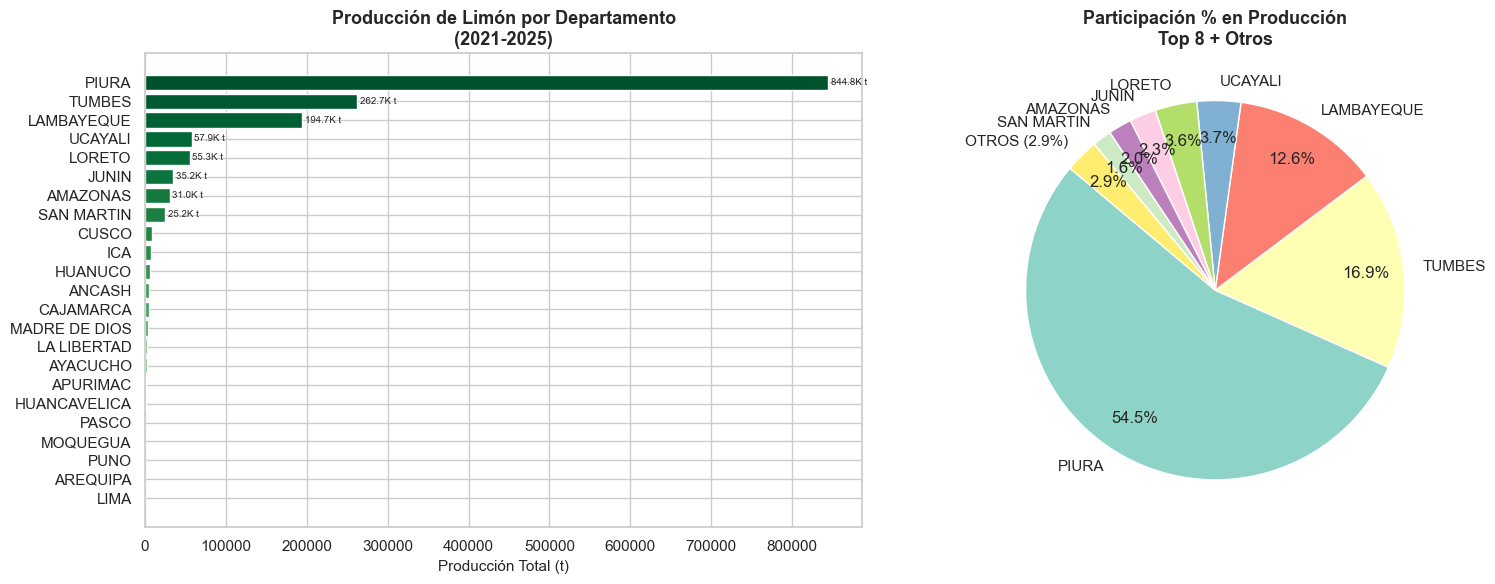

[OK] data\04_reports/g1_produccion_por_dpto.png


In [4]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras horizontales
colors = plt.cm.YlGn(np.linspace(0.4, 0.95, len(geo)))[::-1]
bars = axes[0].barh(geo['Dpto'], geo['produccion_total_t'], color=colors)
axes[0].set_xlabel('Producción Total (t)', fontsize=11)
axes[0].set_title('Producción de Limón por Departamento\n(2021-2025)', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, geo['produccion_total_t']):
    if val > total*0.01:
        axes[0].text(bar.get_width()+total*0.002, bar.get_y()+bar.get_height()/2,
                     f'{val/1000:.1f}K t', va='center', fontsize=7)

# Torta (top 8 + otros)
top8 = geo.head(8).copy()
otros_val = geo.iloc[8:]['produccion_total_t'].sum()
otros_pct = geo.iloc[8:]['pct'].sum()
pie_vals = list(top8['produccion_total_t']) + [otros_val]
pie_labels = list(top8['Dpto'].str[:12]) + [f'OTROS ({otros_pct:.1f}%)']
wedges, texts, autotexts = axes[1].pie(
    pie_vals, labels=pie_labels, autopct='%1.1f%%',
    startangle=140, pctdistance=0.8,
    colors=plt.cm.Set3(np.linspace(0, 1, len(pie_vals))))
axes[1].set_title('Participación % en Producción\nTop 8 + Otros', fontsize=13, fontweight='bold')

plt.tight_layout()
g_path = f"{REPORTS}/g1_produccion_por_dpto.png"
plt.savefig(g_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"[OK] {g_path}")


## 3.3 INDECI — Distribución de Fenómenos de Emergencia

Total eventos: 224


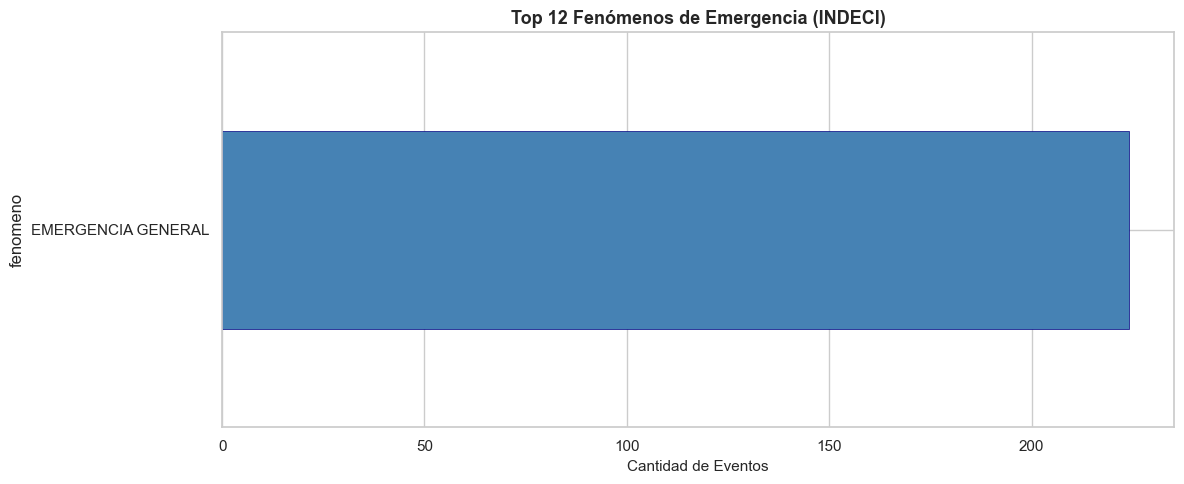

[OK] data\04_reports/g2_indeci_fenomenos.png


In [5]:

df_ev_path = f"{INTERIM}/indeci_eventos_dbf.csv"
if not os.path.exists(df_ev_path):
    # Fallback a resumen si no hay DBFs
    df_ev_path = f"{INTERIM}/indeci_resumen_prov.csv"

if os.path.exists(df_ev_path):
    df_ev = pd.read_csv(df_ev_path, low_memory=False)
    # Homologar nombre de columna si es el resumen
    if 'departamento' in df_ev.columns and 'fenomeno' not in df_ev.columns:
        df_ev['fenomeno'] = 'EMERGENCIA GENERAL' 
        df_ev['personas_afectadas'] = df_ev.get('pers_afectadas', 0)
    
    df_ev['fenomeno'] = df_ev['fenomeno'].astype(str).str.strip().str.upper()
    top_fen = df_ev['fenomeno'].value_counts().head(12)
    print(f"Total eventos: {len(df_ev):,}")
    
    fig, ax = plt.subplots(figsize=(12, 5))
    top_fen.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='navy', linewidth=0.5)
    ax.set_xlabel('Cantidad de Eventos', fontsize=11)
    ax.set_title('Top 12 Fenómenos de Emergencia (INDECI)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    g_path2 = f"{REPORTS}/g2_indeci_fenomenos.png"
    plt.savefig(g_path2, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[OK] {g_path2}")
else:
    print("⚠️ No se encontró data de INDECI (DBF o Resumen).")


## 3.4 AGRARIA.PE — Frecuencia de Noticias

Total noticias: 528

Noticias por año:
anho
2021     44
2022    133
2023    118
2024    108
2025    125


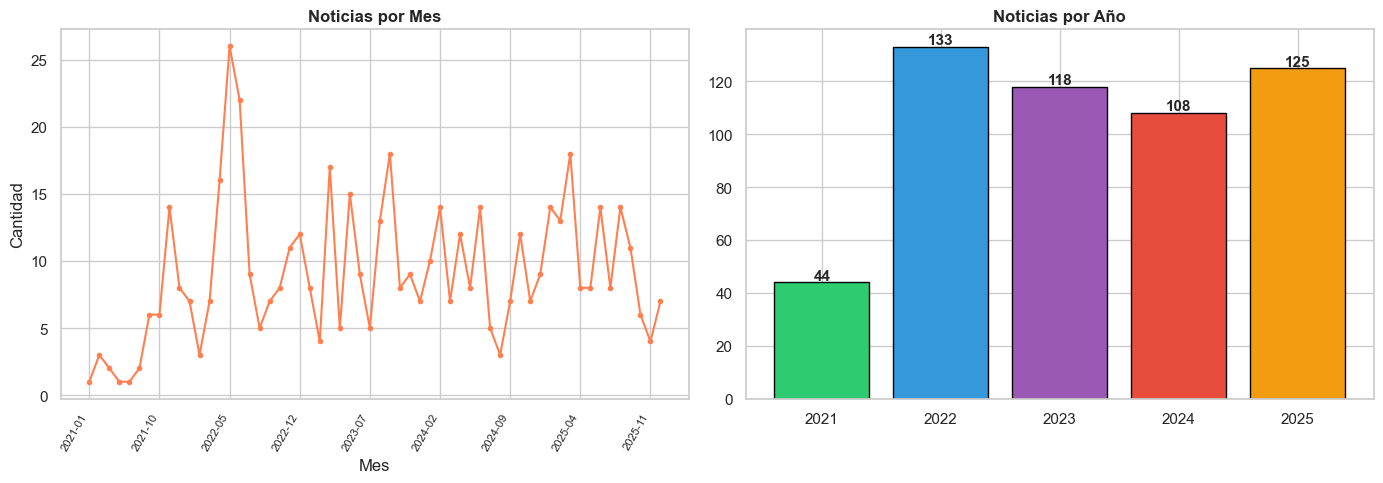

[OK] data\04_reports/g3_noticias_frecuencia.png


In [6]:

df_n = pd.read_csv(f"{INTERIM}/agraria_noticias_raw.csv")
df_n['fecha'] = pd.to_datetime(df_n['fecha'], errors='coerce')
df_n['anho'] = df_n['fecha'].dt.year
df_n['mes_periodo'] = df_n['fecha'].dt.to_period('M').astype(str)

print(f"Total noticias: {len(df_n)}")
print("\nNoticias por año:")
print(df_n['anho'].value_counts().sort_index().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
freq_mes = df_n.groupby('mes_periodo').size()
freq_mes.plot(ax=axes[0], color='coral', marker='o', markersize=3, linewidth=1.5)
axes[0].set_title('Noticias por Mes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mes'); axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=60)
step = max(1, len(freq_mes)//8)
axes[0].set_xticks(range(0, len(freq_mes), step))
axes[0].set_xticklabels(freq_mes.index[::step], rotation=60, ha='right', fontsize=8)

freq_anho = df_n.groupby('anho').size()
bars = axes[1].bar(freq_anho.index.astype(str), freq_anho.values,
                   color=['#2ecc71','#3498db','#9b59b6','#e74c3c','#f39c12'], edgecolor='black')
axes[1].set_title('Noticias por Año', fontsize=12, fontweight='bold')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 str(int(bar.get_height())), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
g_path3 = f"{REPORTS}/g3_noticias_frecuencia.png"
plt.savefig(g_path3, dpi=150, bbox_inches='tight')
plt.show()
print(f"[OK] {g_path3}")


## 3.5 NASA POWER — EDA Climático
Analizamos las tendencias de temperatura y precipitación de la NASA POWER. Se incluyen gráficos pre-procesados de la fase de ingeniería de datos climáticos.

📊 Visualización de Gráficos Pre-procesados NASA:

### Distribución de Variables Climáticas


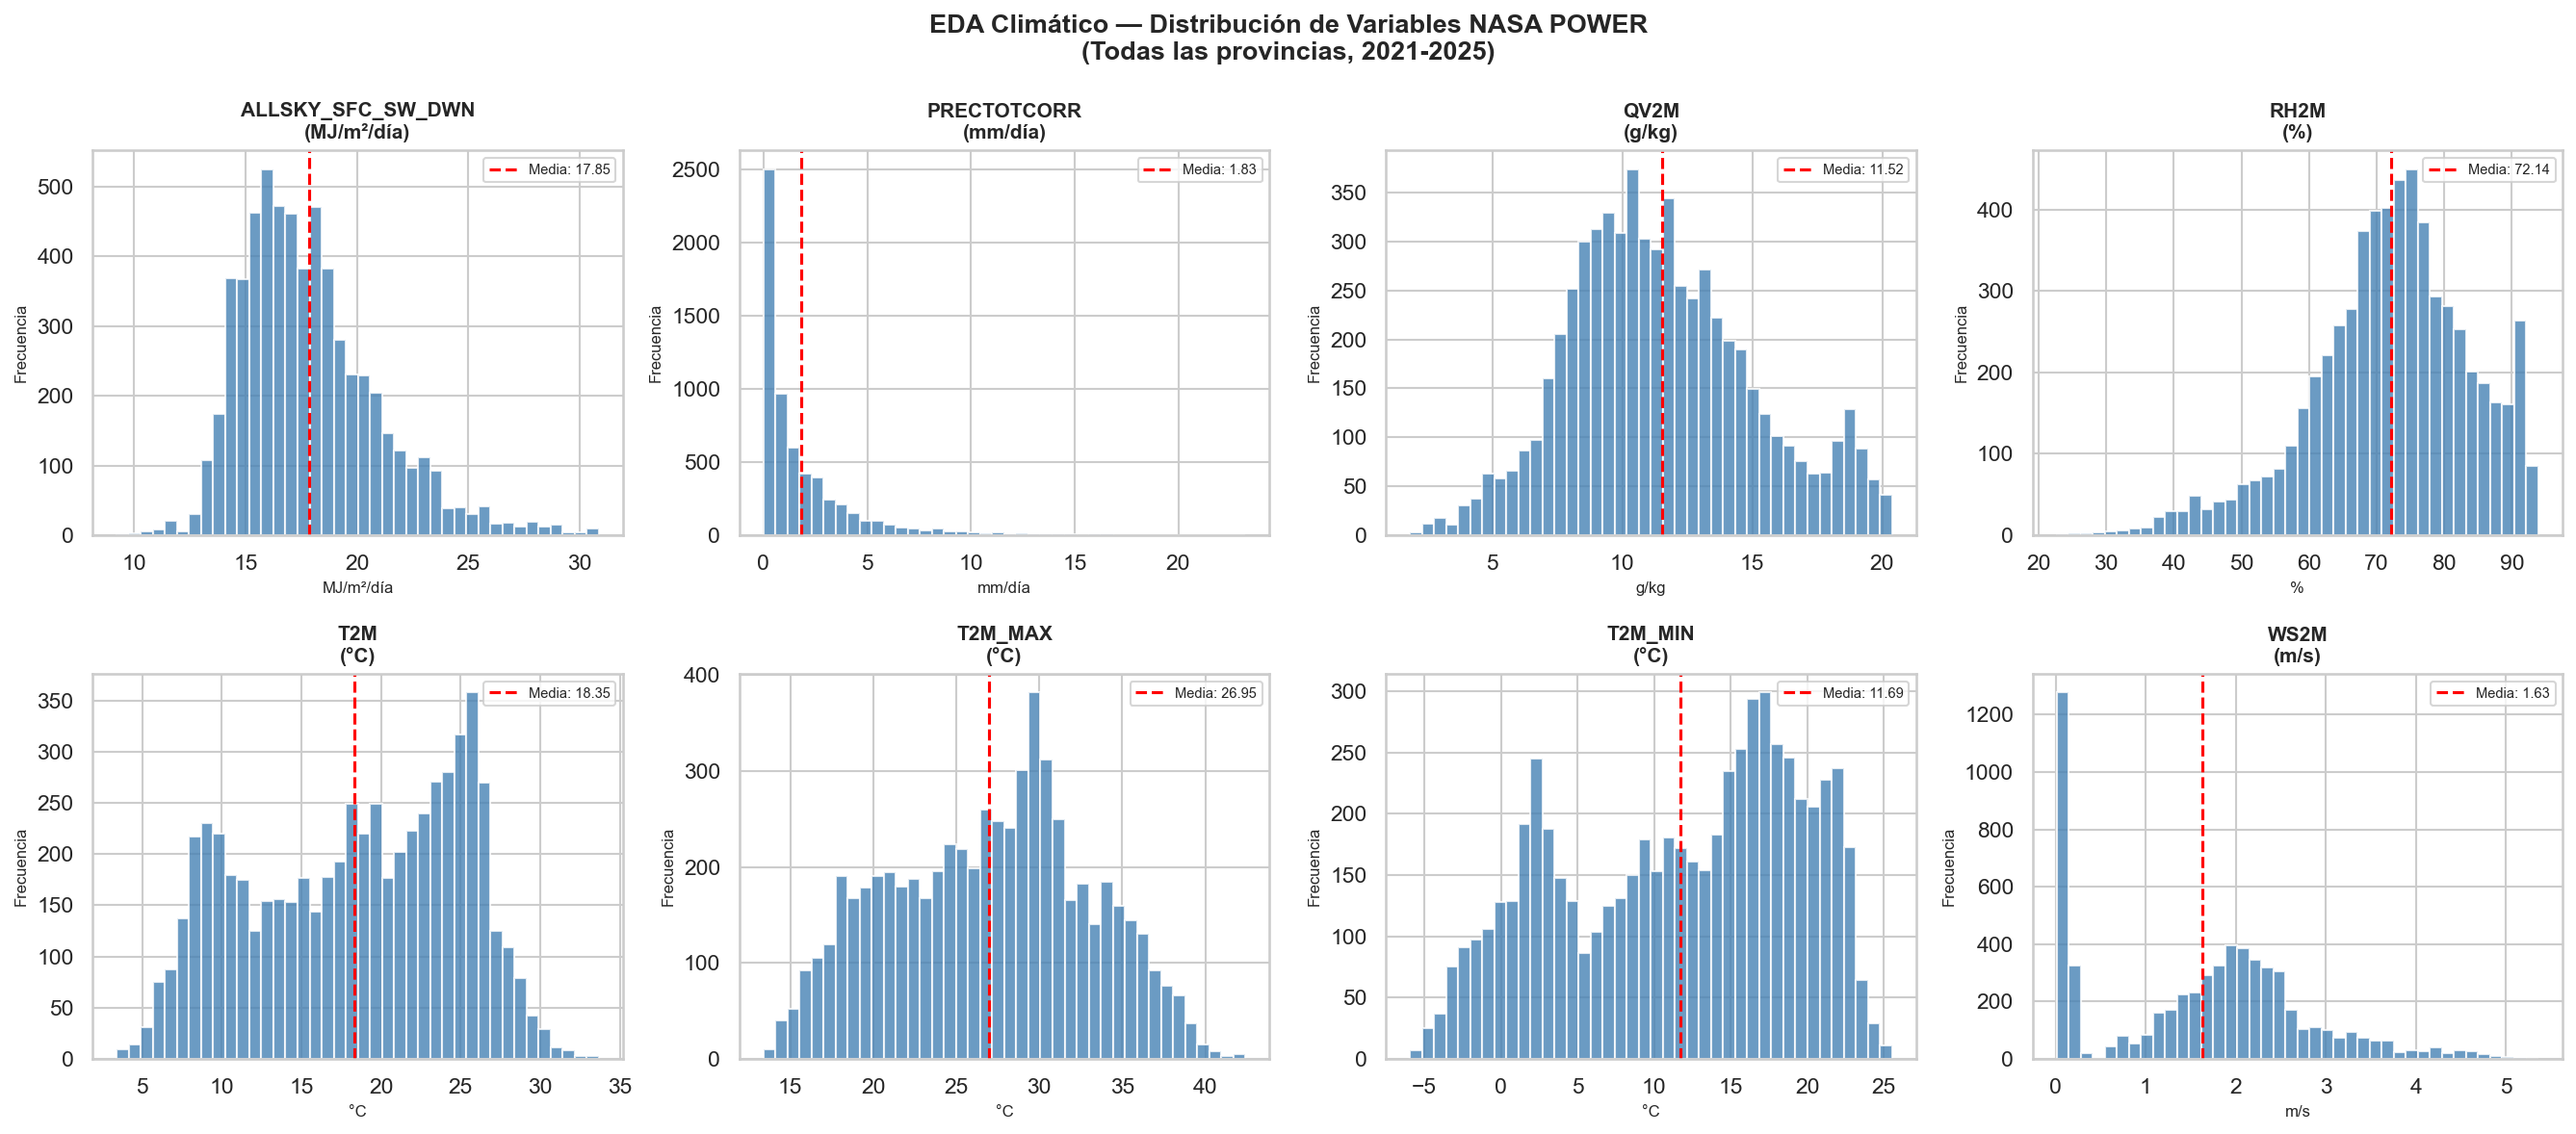

**Interpretación:** Muestra la dispersión y densidad de T2M y PRECTOTCORR. Permite identificar sesgos y la escala de las variables climáticas.

### Cobertura Espacial de Datos NASA


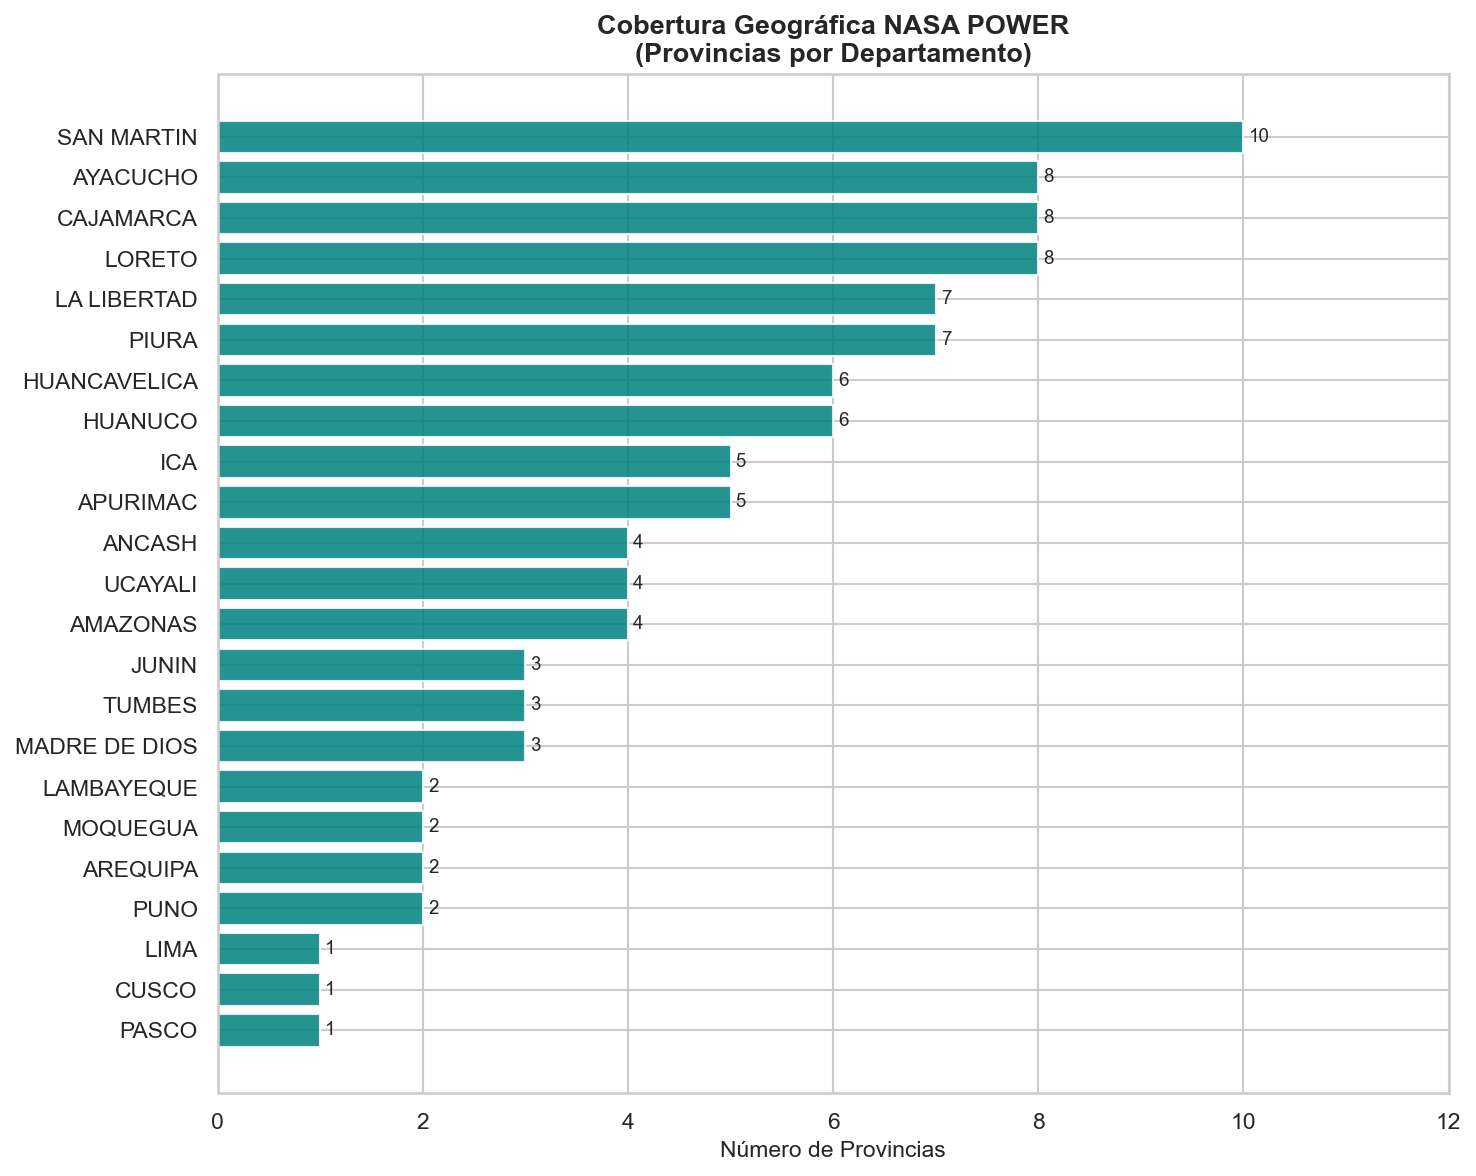

**Interpretación:** Valida la disponibilidad de datos por departamento. Una cobertura uniforme garantiza que el modelo LSTM aprenda de todas las regiones productoras.

### Serie Temporal: Temperatura (T2M)


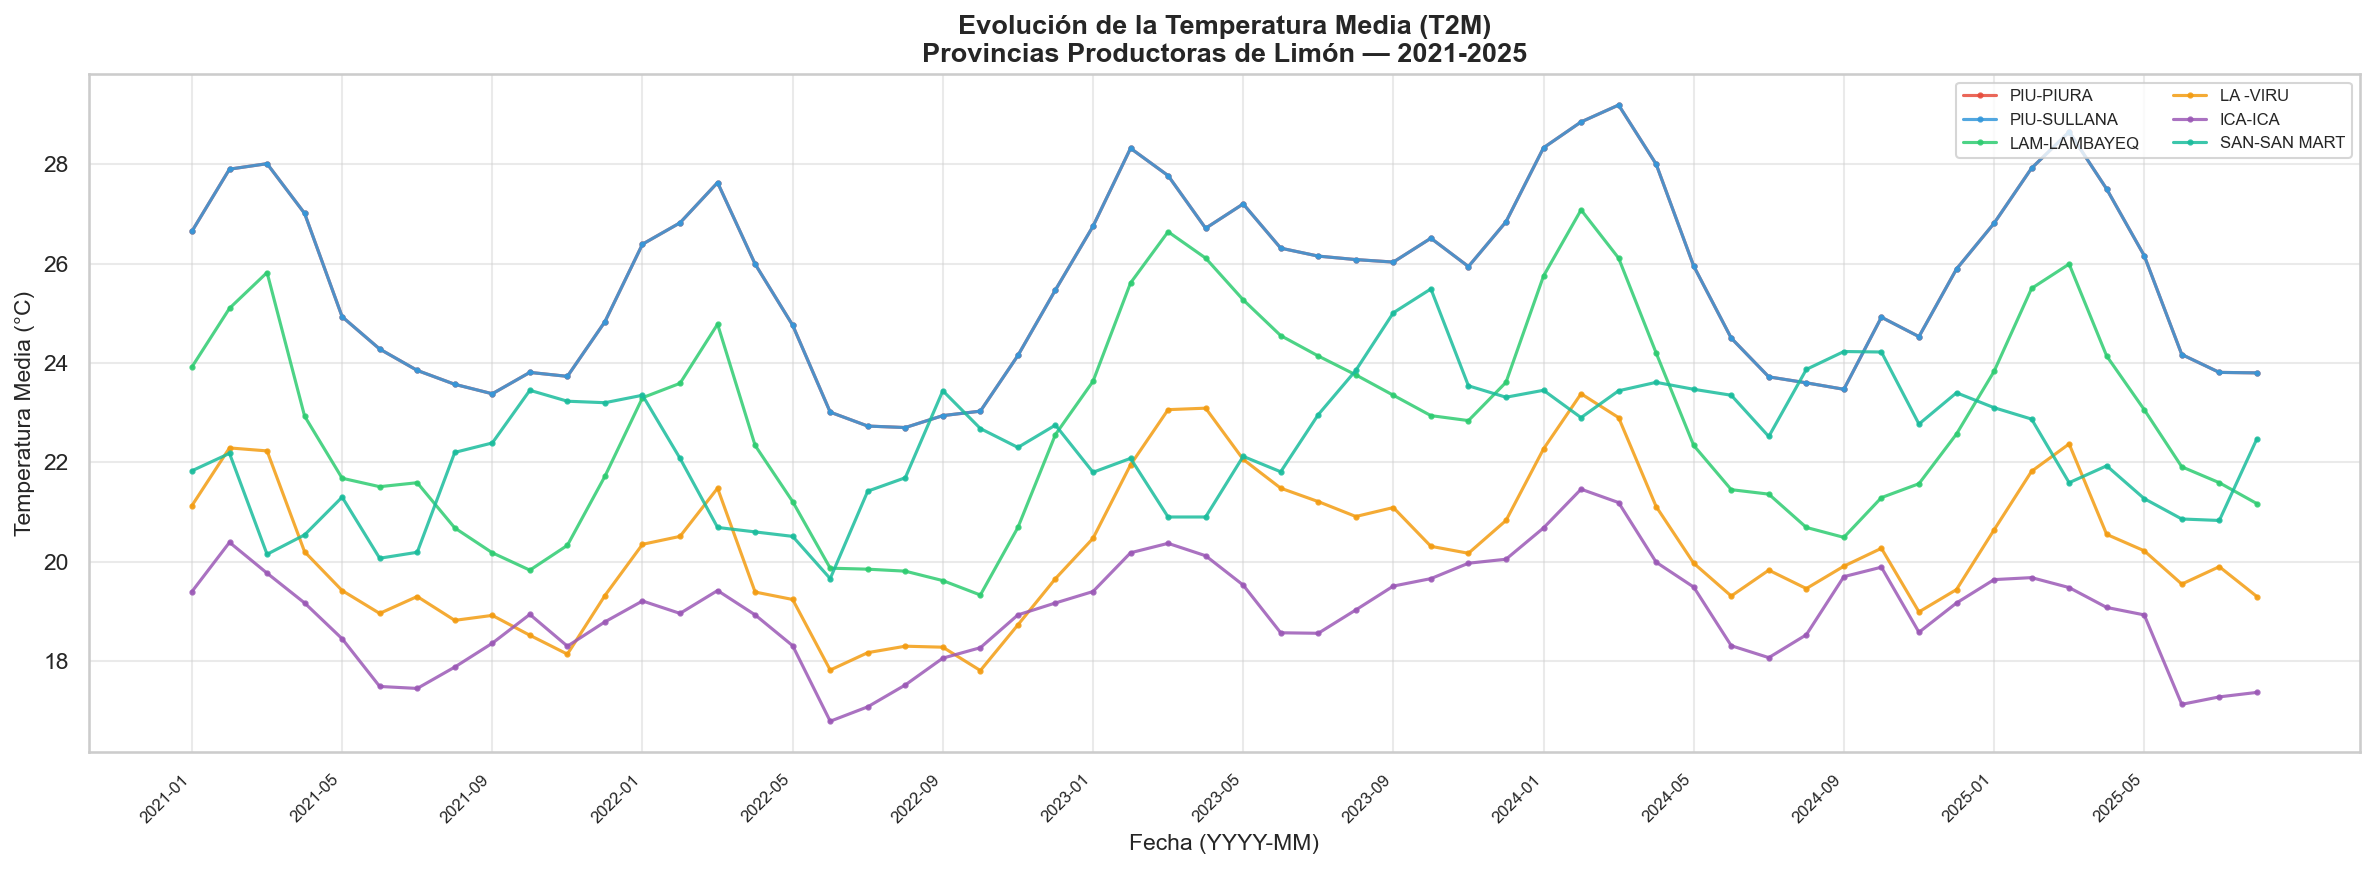

**Interpretación:** Observamos la evolución mensual de la temperatura media. Los picos térmicos pueden correlacionarse con periodos de estrés hídrico en el limón.

### Serie Temporal: Precipitación (PRECTOTCORR)


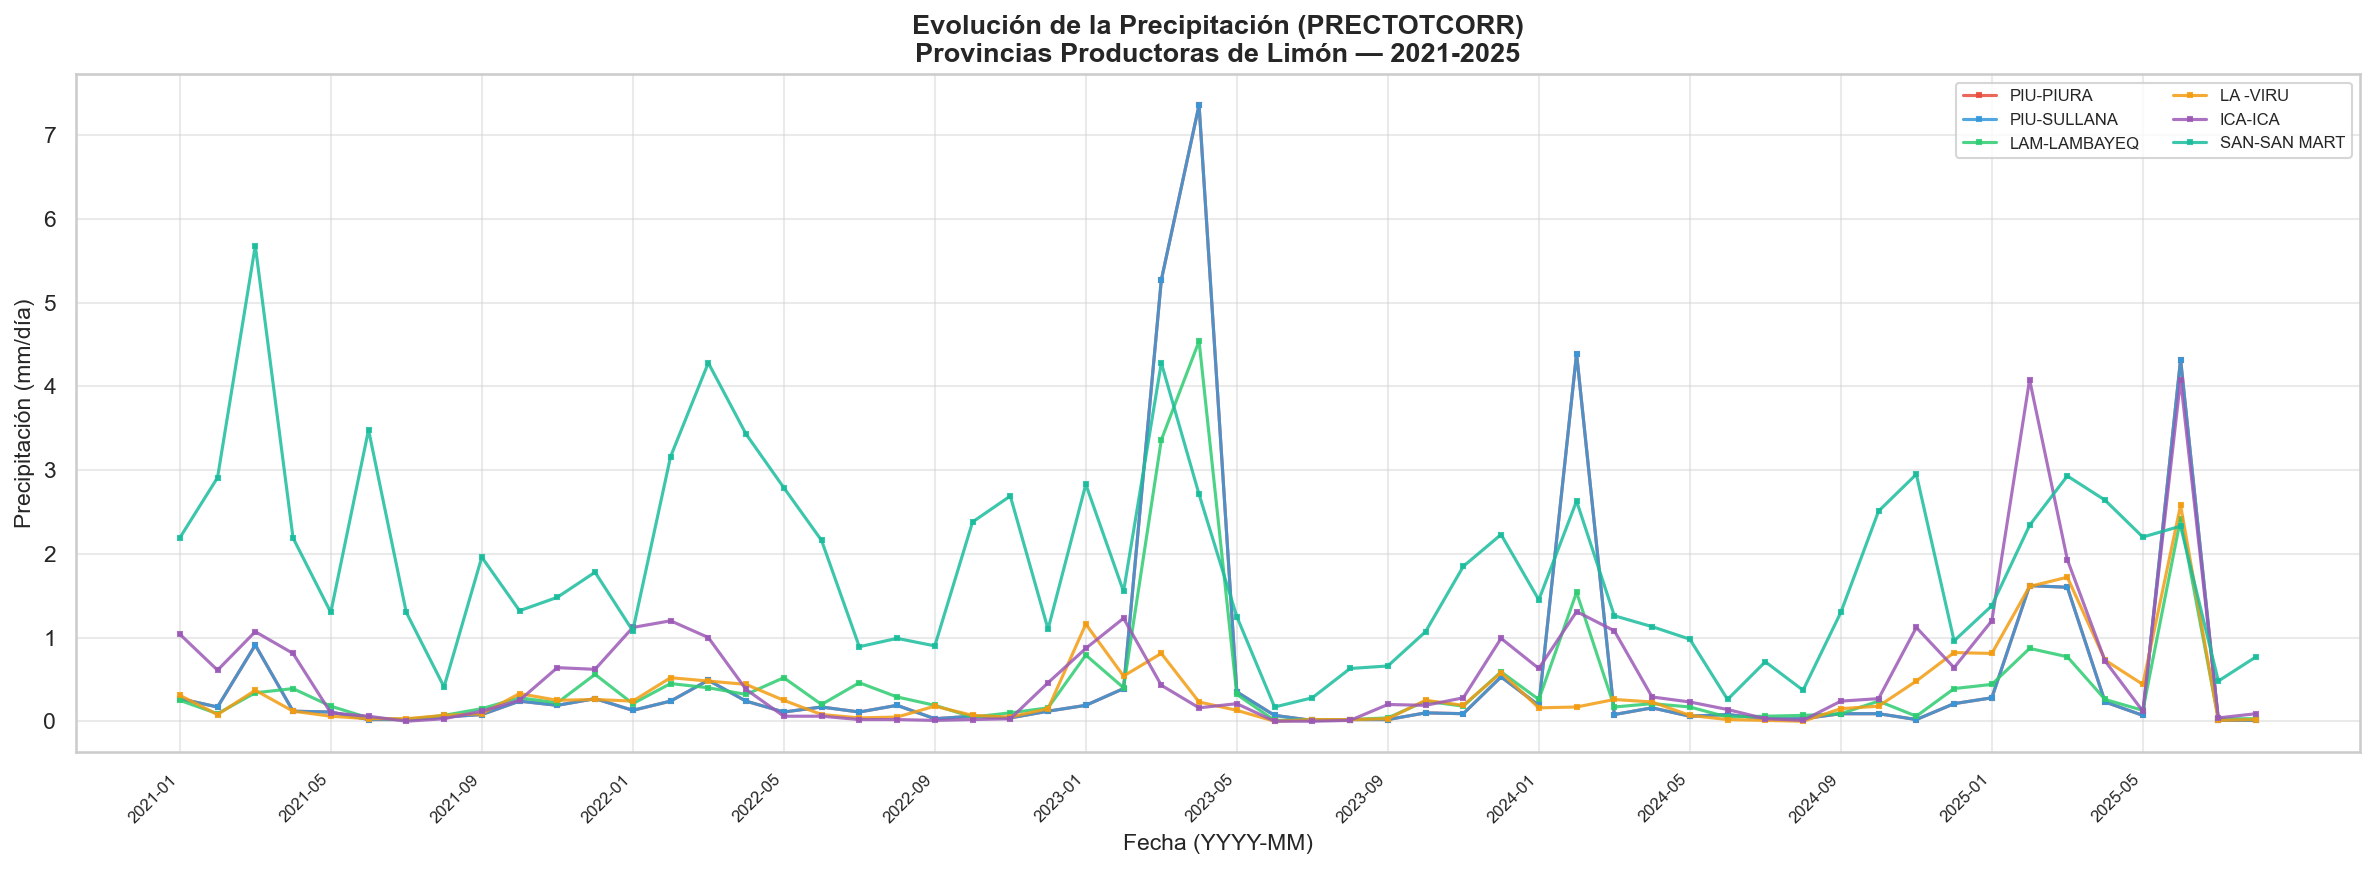

**Interpretación:** Muestra la variabilidad de lluvias. Picos extremos indican posibles eventos de El Niño que afectan la floración y cosecha.

### Matriz de Correlación Climática


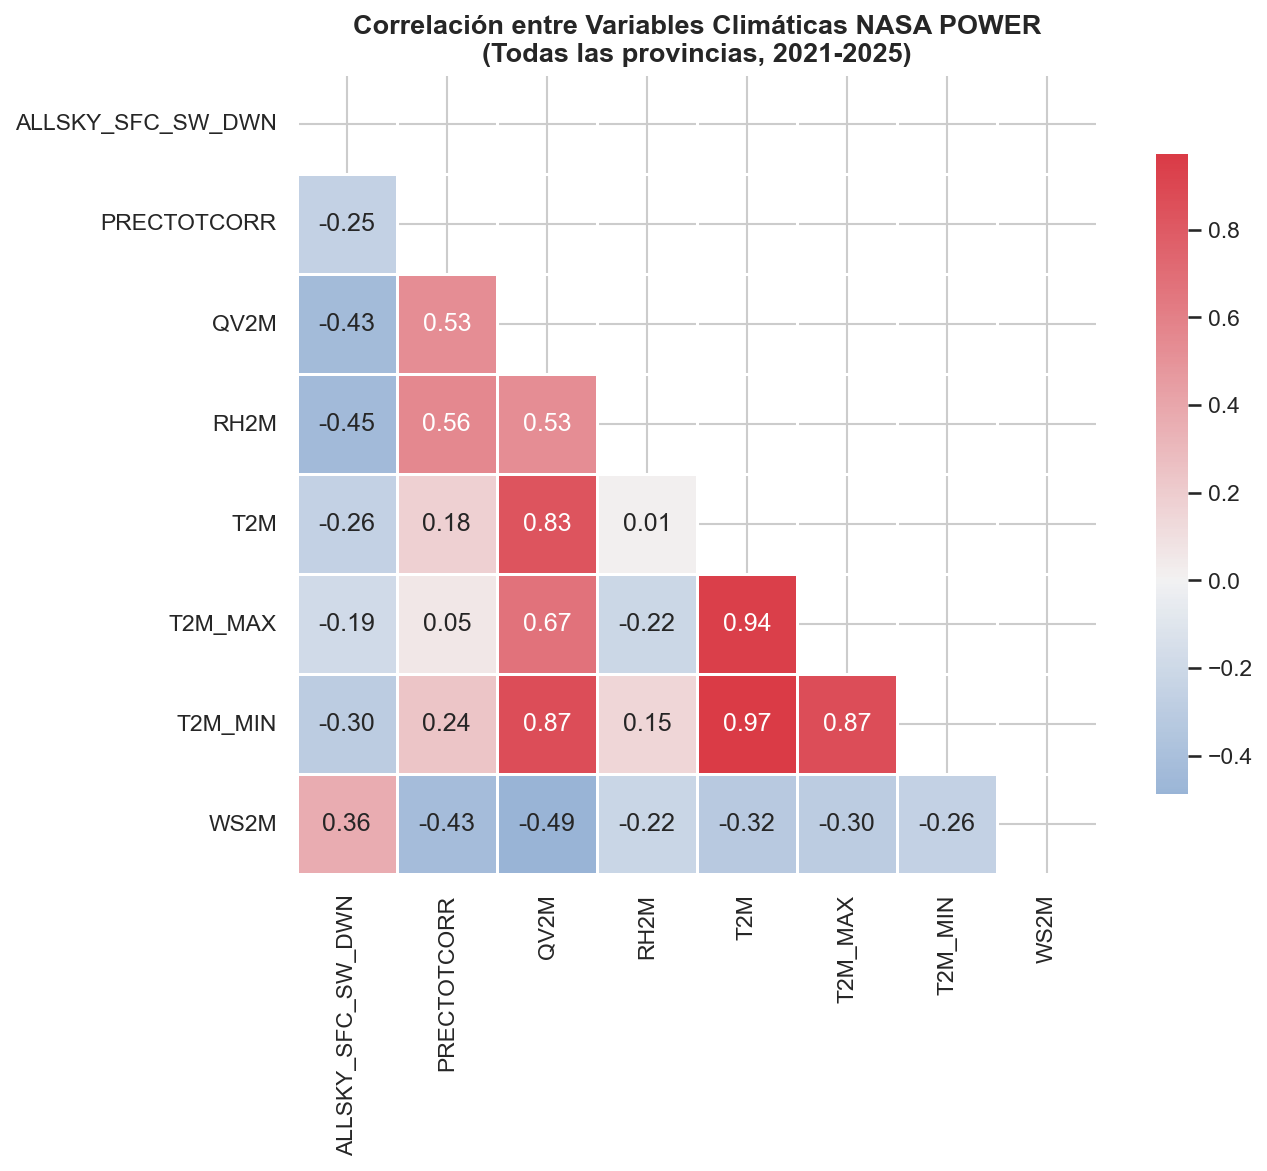

**Interpretación:** Identifica la relación interna entre variables NASA. Ayuda a descartar multicolinealidad entre temperaturas máximas, mínimas y humedad.

### Análisis de Estacionalidad de Temperatura


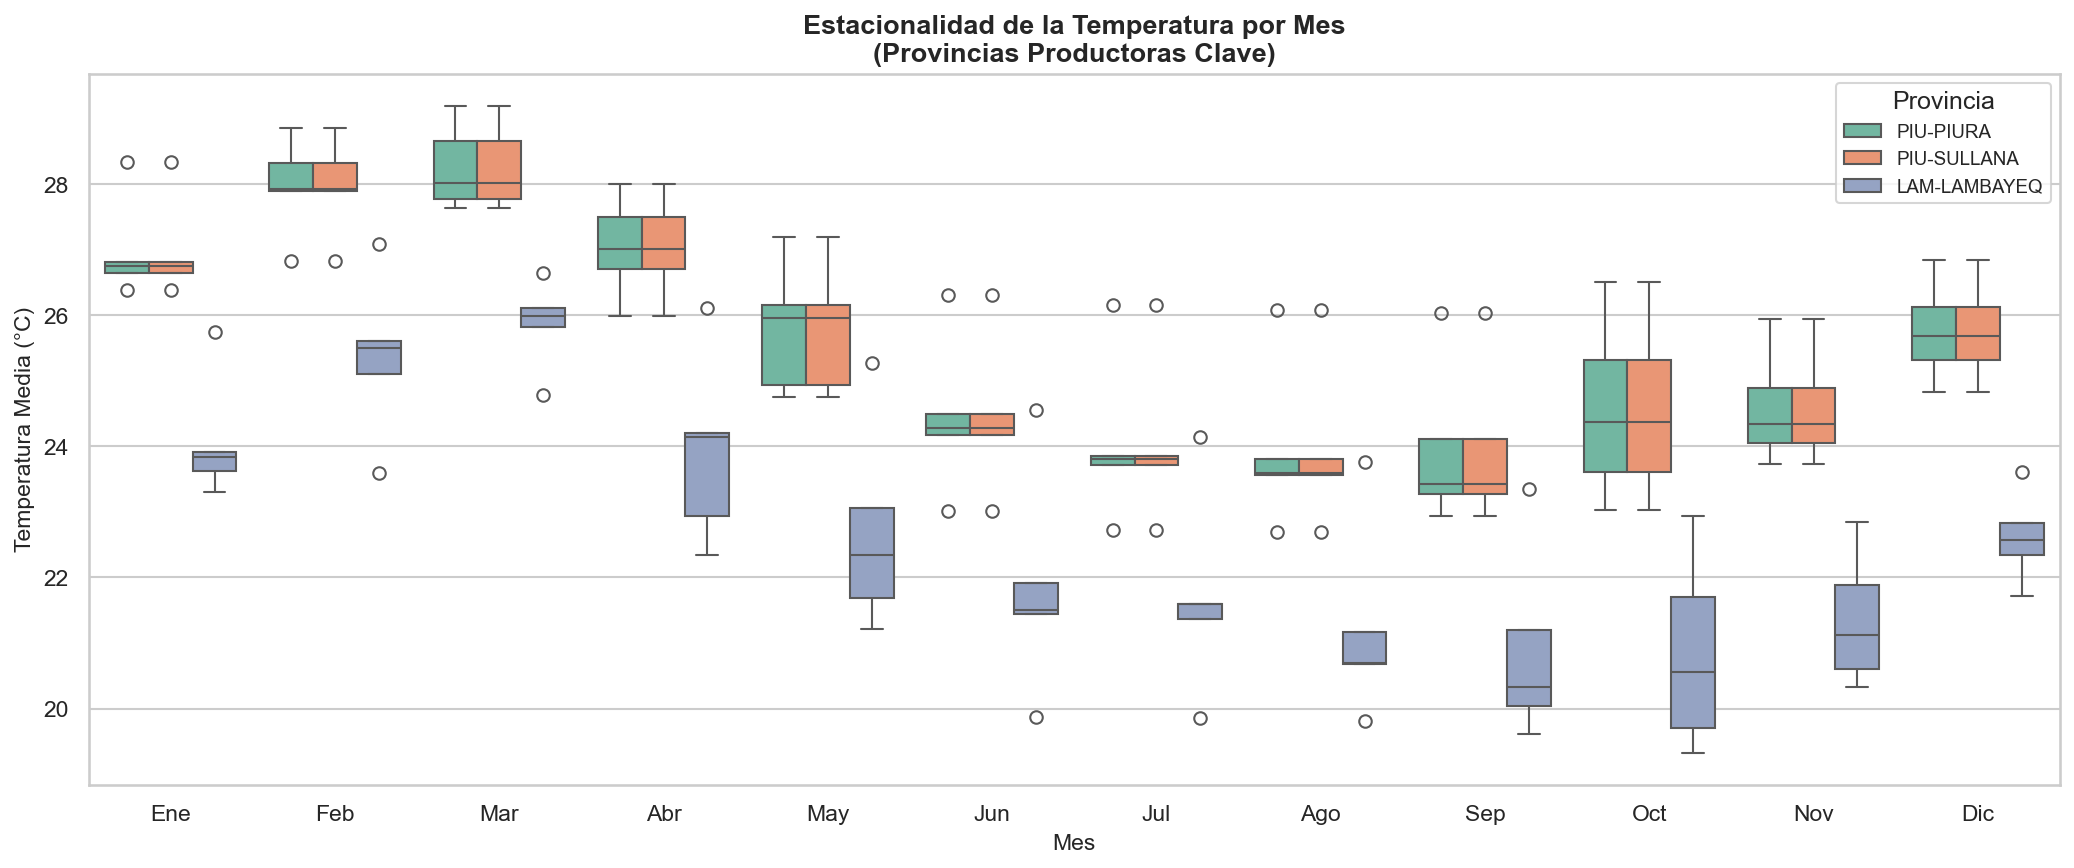

**Interpretación:** Visualiza patrones cíclicos anuales. Es fundamental para que el modelo entienda los ciclos biológicos estacionales del cultivo.


In [7]:

from IPython.display import Image, display

nasa_reports_dir = "data/03_processed_nasa/reports"
if os.path.exists(nasa_reports_dir):
    print("📊 Visualización de Gráficos Pre-procesados NASA:")
    
    # Lista de gráficos con títulos y descripciones interpretativas
    nasa_graphs = [
        ("Distribución de Variables Climáticas", "g1_eda_distribucion.png", 
         "Muestra la dispersión y densidad de T2M y PRECTOTCORR. Permite identificar sesgos y la escala de las variables climáticas."),
        ("Cobertura Espacial de Datos NASA", "g2_eda_cobertura.png", 
         "Valida la disponibilidad de datos por departamento. Una cobertura uniforme garantiza que el modelo LSTM aprenda de todas las regiones productoras."),
        ("Serie Temporal: Temperatura (T2M)", "g3_temperatura_series.png", 
         "Observamos la evolución mensual de la temperatura media. Los picos térmicos pueden correlacionarse con periodos de estrés hídrico en el limón."),
        ("Serie Temporal: Precipitación (PRECTOTCORR)", "g4_precipitacion_series.png", 
         "Muestra la variabilidad de lluvias. Picos extremos indican posibles eventos de El Niño que afectan la floración y cosecha."),
        ("Matriz de Correlación Climática", "g5_correlacion_clima.png", 
         "Identifica la relación interna entre variables NASA. Ayuda a descartar multicolinealidad entre temperaturas máximas, mínimas y humedad."),
        ("Análisis de Estacionalidad de Temperatura", "g6_estacionalidad_temp.png", 
         "Visualiza patrones cíclicos anuales. Es fundamental para que el modelo entienda los ciclos biológicos estacionales del cultivo.")
    ]
    
    for title, img_name, desc in nasa_graphs:
        img_path = os.path.join(nasa_reports_dir, img_name)
        if os.path.exists(img_path):
            print(f"\n### {title}")
            display(Image(filename=img_path))
            print(f"**Interpretación:** {desc}")
        else:
            print(f"⚠️ No se encontró {img_name}")
else:
    print("⚠️ Directorio de reportes NASA no encontrado.")


In [8]:

# Guardar reporte geográfico TXT
report_path = f"{REPORTS}/reporte_geografico_limon.txt"
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("REPORTE ESTRUCTURADO: PRODUCCIÓN DE LIMÓN POR DEPARTAMENTO (2021-2025)\n")
    f.write("="*75+"\n")
    f.write(f"{'DEPARTAMENTO':<25} {'PRODUCCIÓN (t)':>15} {'PROVINCIAS':>10} {'% PART.':>8}\n")
    f.write("-"*75+"\n")
    for _, r in geo.iterrows():
        f.write(f"{r['Dpto']:<25} {r['produccion_total_t']:>15,.2f} {int(r['n_provincias']):>10} {r['pct']:>7.2f}%\n")
    f.write("-"*75+"\n")
    f.write(f"{'TOTAL':<25} {total:>15,.2f} {'':>10} {'100.00%':>8}\n")

print(f"[OK] Reporte guardado: {report_path}")
print()
print("[ACTIVIDAD 03] COMPLETADA.")
print(f"  Departamentos analizados: {len(geo)}")
print(f"  Gráficos generados: g1, g2, g3 en {REPORTS}/")


[OK] Reporte guardado: data\04_reports/reporte_geografico_limon.txt

[ACTIVIDAD 03] COMPLETADA.
  Departamentos analizados: 23
  Gráficos generados: g1, g2, g3 en data\04_reports/
